# fxcarry: from Bloomberg parquet to a backtested currency book

fxcarry turns a folder of long-format Bloomberg parquet files, one row per ticker, date and
field, into a backtested cross-sectional currency book. A catalog says which tickers exist and
how each currency is quoted, a source loads and pivots the parquet, a signal ranks currencies
by carry, a weighting rule turns the ranking into positions, and an optional overlay hedges
each leg's crash side with options. What comes out the other end is a return series and the
statistics that describe it.

This notebook is for someone who has not opened the library before. It draws the object graph
once, runs the shortest path across it in one screen, and then points to the eight notebooks
that each work through one module in full.

## The object graph

```
Catalog          which tickers exist, and what each currency's conventions are
   |
   v
QuoteSource      read long parquet, pivot to date by currency
   |
   +--> Quotes           mid, bid and ask on one index
   |       |
   |       v
   |    SpotForward      spot, outright forward, carry, excess return
   |       |
   +--> VolSurface --> Smile
           |               |
           v               v
        Book  <-------  Overlay  <--  Instrument  <--  PricingModel
           |
           v
        Performance, HAC, FactorModel, LinearSDF
```

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# nbconvert runs with this notebook's folder as the working directory, so walk up
# rather than assume how deep the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "data" / "raw").is_dir())
DATA = ROOT / "data" / "raw"
TAU = 1.0 / 12.0

## The whole library, on one screen

The next cell is the entire pipeline, start to finish: read two parquet files, build a
spot-forward panel, score and weight a monthly book, and summarize what it earned. Every line
names one class from the object graph above, and each one gets its own notebook among the
eight that follow.

In [2]:
from fxcarry import (Book, Carry, Catalog, ParquetSource, Performance,
                     SpotForward, TopBottom)

catalog = Catalog.default()
source = ParquetSource(DATA / "spot_daily.parquet", DATA / "fwd_points_1m_daily.parquet")

spot = source.quotes(catalog.label_map("spot"), freq="M")
points = source.quotes(catalog.label_map("forward", "1M"), freq="M")
curves = SpotForward.from_quotes(spot, points, catalog, TAU)

book = Book(curves, Carry(), TopBottom(5))
Performance(book.returns()).summary().round(4)

,mean,volatility,sharpe,skew,kurtosis,win_rate,worst,max_drawdown,mean_se,n_obs
return,0.0606,0.0665,0.9117,-0.3786,1.5129,0.6282,-0.0787,-0.1952,0.0106,511.0


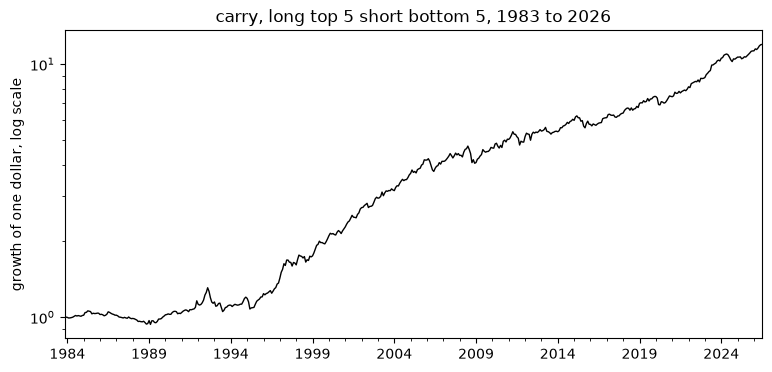

In [3]:
ax = book.nav().plot(logy=True, figsize=(9, 4), color="black", linewidth=1)
ax.set_title(f"carry, long top 5 short bottom 5, {book.nav().index[0]:%Y} to "
             f"{book.nav().index[-1]:%Y}")
ax.set_ylabel("growth of one dollar, log scale")
plt.show()

## Where to go from here

Each of the eight notebooks below takes one module from the object graph and works through it
end to end, usually with a check that the module's own arithmetic agrees with something
computed by hand. Read them in order the first time; after that, read whichever one covers
what you are stuck on.

| notebook | what it covers |
|---|---|
| `01_catalog` | currency identity: pairs, point scales, ticker builders, and the parser that inverts them |
| `02_quotes` | the one loading pipeline, from a long parquet file to mid, bid and ask panels |
| `03_curves` | spot and forward levels turned into carry and excess return |
| `04_vol` | unpacking a quoted smile, at the money plus risk reversal plus butterfly, into a vol at any quoted delta |
| `05_options` | pricing model, instrument and overlay: three layers that price a hedge |
| `06_strategy` | signal, weighting, overlay and cost model meeting in `Book` |
| `07_stats` | `Performance`, `HAC`, `Realized`, `FactorModel` and `LinearSDF` describing and testing a return series, plus `RollingOLS` and `Shrinkage`, two domain-free tools used on it |
| `08_reference` | the literal tables the catalog and the loaders are built from |

For what the parquet files themselves contain, ticker by ticker, see the three notebooks under
`notebooks/data_dictionary/`.